In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv(r"C:\Users\Welcome\Desktop\data\QuickCommerce platforms — Blinkit, Swiggy Instamart, and JioMart.-checkpoint.csv")

In [9]:
print(df.shape)

(100000, 18)


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   order_id               100000 non-null  object
 1   customer_id            100000 non-null  object
 2   platform_name          100000 non-null  object
 3   product_category_id    100000 non-null  int64 
 4   order_datetime         100000 non-null  object
 5   delivery_time_min      100000 non-null  int64 
 6   order_value_inr        100000 non-null  int64 
 7   delivery_delay         100000 non-null  object
 8   refund_requested       100000 non-null  int64 
 9   service_rating         100000 non-null  int64 
 10  customer_feedback      100000 non-null  object
 11  product_category_name  100000 non-null  object
 12  sla_delay              100000 non-null  object
 13  Segment                100000 non-null  object
 14  hour                   100000 non-null  int64 
 15  w

In [12]:
print(df.describe(include='all'))

         order_id customer_id platform_name  product_category_id  \
count      100000      100000        100000        100000.000000   
unique     100000        9000             3                  NaN   
top     ORD000001    CUST8779       Blinkit                  NaN   
freq            1          26         40695                  NaN   
mean          NaN         NaN           NaN             3.488570   
std           NaN         NaN           NaN             1.708437   
min           NaN         NaN           NaN             1.000000   
25%           NaN         NaN           NaN             2.000000   
50%           NaN         NaN           NaN             3.000000   
75%           NaN         NaN           NaN             5.000000   
max           NaN         NaN           NaN             6.000000   

          order_datetime  delivery_time_min  order_value_inr delivery_delay  \
count             100000      100000.000000    100000.000000         100000   
unique             22191 

In [21]:
df = df.drop_duplicates() # no duplicates in this data

In [22]:

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [23]:
print(df.describe())

       product_category_id  delivery_time_min  order_value_inr  \
count        100000.000000      100000.000000    100000.000000   
mean              3.488570          13.352990       429.955360   
std               1.708437           5.158344       403.113784   
min               1.000000           5.000000        19.000000   
25%               2.000000          10.000000       166.000000   
50%               3.000000          13.000000       343.000000   
75%               5.000000          15.000000       534.000000   
max               6.000000          76.000000      5445.000000   

       refund_requested  service_rating          hour     order_hour  
count     100000.000000   100000.000000  100000.00000  100000.000000  
mean           0.088710        3.965890      11.83150      12.330950  
std            0.284326        1.198908       6.87804       6.642679  
min            0.000000        1.000000       0.00000       0.000000  
25%            0.000000        3.000000       6.00

In [40]:
#VISUALIZATION


In [44]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

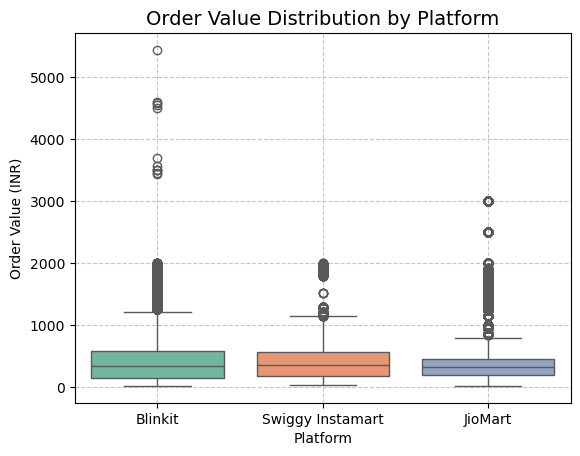

In [54]:
sns.boxplot(
    x='platform_name',
    y='order_value_inr',
    hue='platform_name',   # fixes palette warning
    data=df,
    palette="Set2",
    legend=False) 
plt.title("Order Value Distribution by Platform", fontsize=14)
plt.xlabel("Platform")
plt.ylabel("Order Value (INR)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [56]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

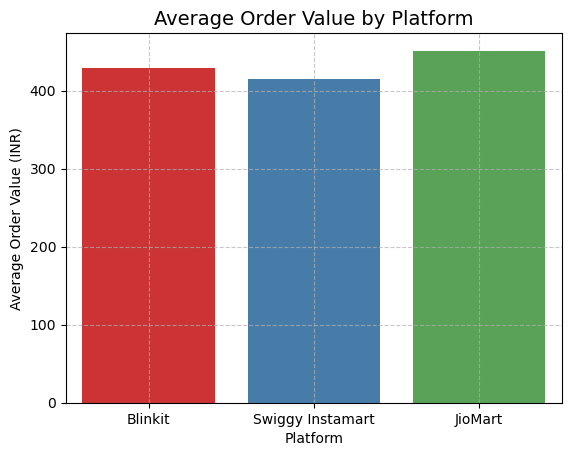

In [59]:
sns.barplot(
    x='platform_name',
    y='order_value_inr',
    hue='platform_name',       # fixes palette warning
    data=df,
    estimator=np.mean,         # average values
    errorbar=None,             # replaces deprecated ci=None
    palette="Set1",
    legend=False
)
plt.title("Average Order Value by Platform", fontsize=14)
plt.xlabel("Platform")
plt.ylabel("Average Order Value (INR)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

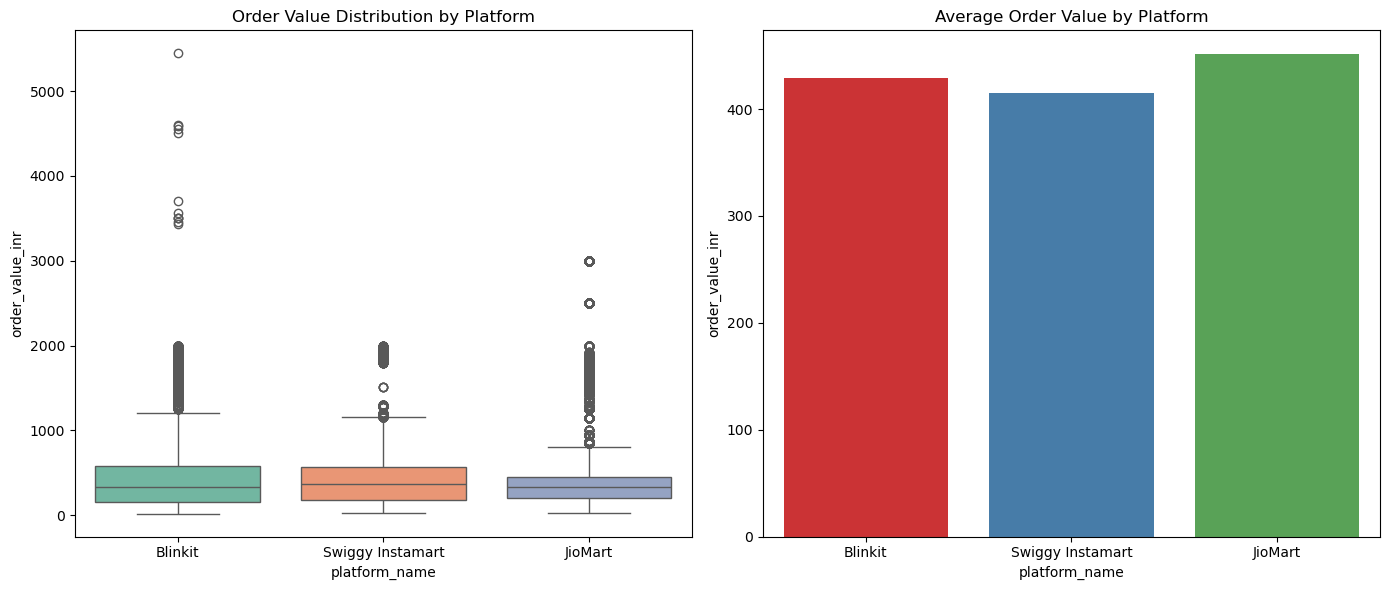

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.boxplot(x='platform_name', y='order_value_inr', hue='platform_name', data=df, palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Order Value Distribution by Platform")

sns.barplot(x='platform_name', y='order_value_inr', hue='platform_name', data=df, estimator=np.mean, errorbar=None, palette="Set1", legend=False, ax=axes[1])
axes[1].set_title("Average Order Value by Platform")

plt.tight_layout()
plt.show()


In [62]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

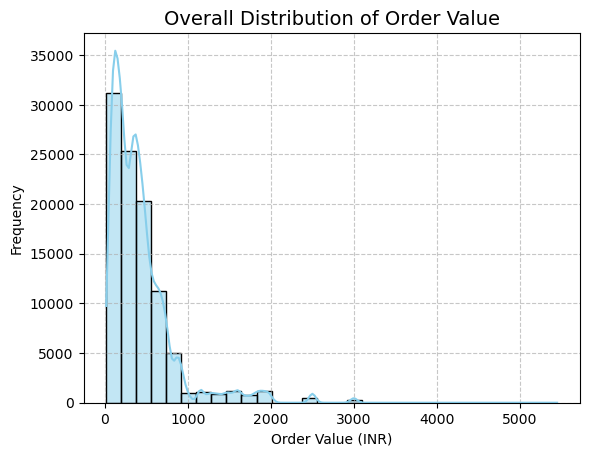

In [64]:
sns.histplot(df['order_value_inr'], bins=30, kde=True, color='skyblue')
plt.title("Overall Distribution of Order Value", fontsize=14)
plt.xlabel("Order Value (INR)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [65]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

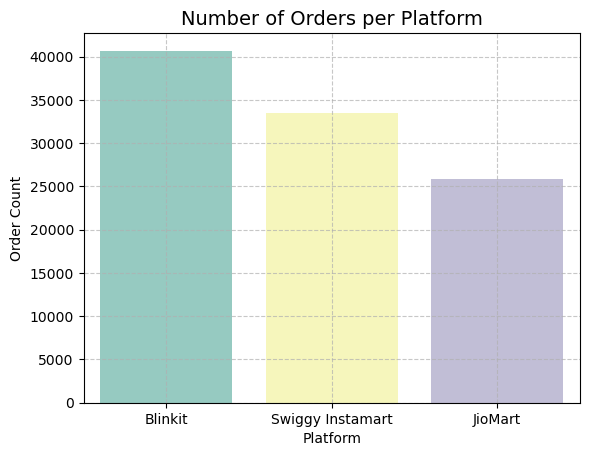

In [69]:
sns.countplot(
    x='platform_name',
    hue='platform_name',       # fixes palette warning
    data=df,
    palette="Set3",
    legend=False               # hides duplicate legend
)
plt.title("Number of Orders per Platform", fontsize=14)
plt.xlabel("Platform")
plt.ylabel("Order Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [70]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

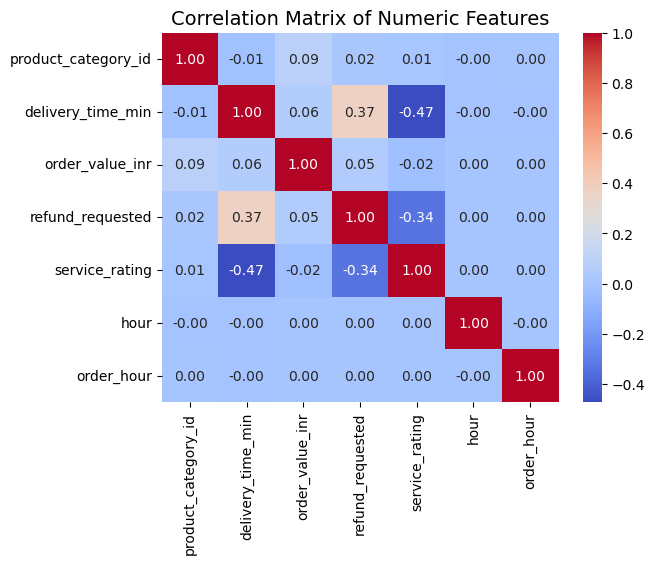

In [103]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Features", fontsize=14)
plt.show()

In [109]:
# Run this first to see your actual columns
print(df.columns.tolist())
print(df.head(2))

['order_id', 'customer_id', 'platform_name', 'product_category_id', 'order_datetime', 'delivery_time_min', 'order_value_inr', 'delivery_delay', 'refund_requested', 'service_rating', 'customer_feedback', 'product_category_name', 'sla_delay', 'segment', 'hour', 'weekday', 'date', 'order_hour']
    order_id customer_id platform_name  product_category_id    order_datetime  \
0  ORD000001    CUST2824       Blinkit                    4  16-05-2025 14:31   
1  ORD000002    CUST1409       Blinkit                    1  02-05-2025 18:45   

   delivery_time_min  order_value_inr delivery_delay  refund_requested  \
0                 15              382             No                 0   
1                  6               90             No                 0   

   service_rating              customer_feedback product_category_name  \
0               5  Fast delivery, great service!   Fruits & Vegetables   
1               5            Quick and reliable!                Dairy    

  sla_delay     s

In [115]:
df['order_datetime'] = pd.to_datetime(df['order_datetime'])  # replace 'order_date' with actual date column
df_grouped = df.groupby('order_datetime')['order_value_inr'].mean().reset_index()  # replace both column names

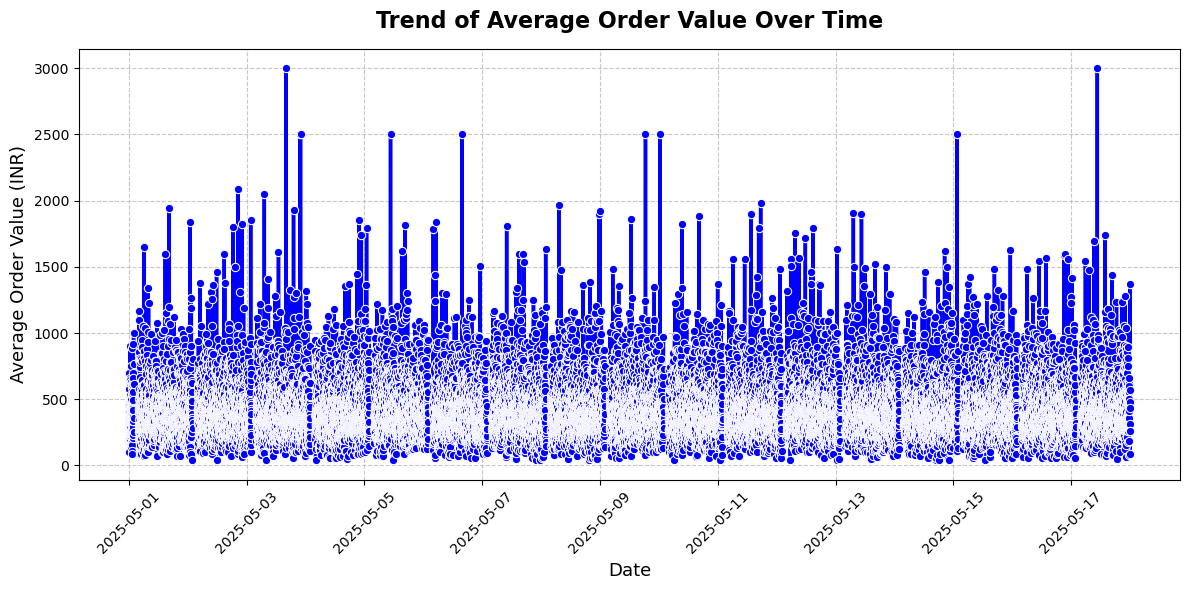

In [116]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    x='order_datetime',
    y='order_value_inr',
    data=df_grouped,
    marker="o",
    color="blue",
    linewidth=2.5,
    markersize=6,
    ax=ax
)

ax.set_title("Trend of Average Order Value Over Time", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Average Order Value (INR)", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.7)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()